# LOGISTIC REGRESSION FOR SEMANTIC ROLE LABELLING

### Load ConLLu into sentences

In [1]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 7.6 MB/s eta 0:00:000:00:01m eta 0:00:01

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [ ]:
import pandas as pd
from typing import List, Dict
import csv



import spacy
from spacy.tokens import Doc

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

import joblib
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix


nlp = spacy.load("en_core_web_sm")

In [3]:
def load_conll_sentences(path: str):

    sentences = []
    sent = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            
            line = line.rstrip("\n")
        
            #  save previous sentence 
            # at boundary between 2 sentences
            if line.strip() == "":
                if sent:
                    sentences.append(sent)
                    sent = []
                continue

            # skip comments
            if line.startswith("#"):
                continue

            cols = line.split("\t")
            sent.append(cols)

    if sent:
        sentences.append(sent)

    return sentences

### Preprocessing

In [4]:
def count_sentences_and_tokens(sentences: List):
  """
  Return number of sentences (n_sent)
  and number of tokens from these sentences (n_token)
  """
  n_sent = len(sentences)
  n_token = sum(len(s) for s in sentences)

  return n_sent, n_token


In [5]:
def count_instances_and_tokens(instances:List):
  n_inst = len(instances)
  n_token = sum(len(inst["tokens"]) for inst in instances)

  return n_inst, n_token

### Replicate each sentence for each predicate

In [6]:
def find_predicate_index(sent,
                           label_col,
                           predicate_markers=("V", "B-V")):
  for i, row in enumerate(sent):
    if len(row) > label_col and row[label_col] in predicate_markers:
      return i
  return None



In [7]:
def replicate_sentences(sentences,
                        base_cols: int=11):

  instances = []
  """
  base_cols: the column with specified predicates
  """
  for sent in sentences:

    # check the maximum columns in specific sentence
    # assume it's consistent per token row
    max_cols = max(len(r) for r in sent)

    # nr of predicate-specific label columns
    k = max(0, max_cols-base_cols)

    if k == 0 :
      # sentence has no predicate
      continue

    # rely on k
    for j in range(k):
      label_col = base_cols + j  # 0-based index

      pred_index = find_predicate_index(sent, label_col)

      # fallback if no V marker found
      if pred_index is None:
        continue
        #pred_index = next((i for i,r in enumerate(sent) if len(r) > 9 and r[9] not in ("_", "-", "")), None)


      tokens = [r[1] for r in sent] # FORM column

      #labels = [(r[label_col] if len(r) > label_col else "O") for r in sent]
      labels = [
                    "O" if (len(r) <= label_col or r[label_col] == "_" or r[label_col] == "")
                    else r[label_col]
                    for r in sent
              ]

      instances.append({
                "tokens": tokens,
                "predicate_index": pred_index,
                "labels": labels,
            })
  return instances



In [8]:
def load_and_preprocess(path:str):
  sentences = load_conll_sentences(path)
  before_s, before_t = count_sentences_and_tokens(sentences)

  instances = replicate_sentences(sentences)
  after_s, after_t = count_instances_and_tokens(instances)

  return {
        "sentences": sentences,
        "instances": instances,
        "stats": {
            "before_sentences": before_s,
            "before_tokens": before_t,
            "after_instances": after_s,
            "after_tokens": after_t
        }
    }

## Feature Extraction

**Create a Doc from my token list**

As the warning given from the requirement, the mismatch between Spacy and dataset tokenization might cause potential problems. Thus, I forced spacy to use exactly my dataset's tokenization, so depency parsing and feature extraction remains aligned with my SRL labels.

In [9]:
def create_doc(tokens):
  spaces = [True] * (len(tokens) - 1) + [False]
  doc = Doc(nlp.vocab, words=tokens, spaces=spaces)
  return nlp(doc)

**1) Dependency Path**

The dependency path between a token and the predicate captures the syntactic relationship between them. In many cases, semantic roles correspond to syntactic relations, such as subjects often being ARG0 and objects being ARG1. Including the predicate lemma also helps distinguish patterns that are specific to different predicates. This feature is categorical and therefore works well with Logistic Regression (LR) after vectorization. However, it also makes the space sparse due to the diversity of the dependency path and challenges the LR in finding optimal solution.

In [10]:
def get_ancestors(token):
  ancestors = [token]
  while token.head != token:
      token = token.head
      ancestors.append(token)
  return ancestors

In [11]:
def dependency_path(token, predicate):
  """
  Returns a directed path string 
  from token to predicate
  """

  token_anc = get_ancestors(token)
  predicate_anc = get_ancestors(predicate)

  token_set = {t.i: idx for idx, t in enumerate(token_anc)}
    
  # find lowest common ancestor 
  lca = None
  lca_token_idx = None
  lca_pred_idx = None

  for j, a in enumerate(predicate_anc):
    if a.i in token_set:
      lca = a
      lca_token_idx = token_set[a.i]
      lca_pred_idx = j
      break

  if lca is None:
    return "NOPATH"

  # token -> LCA (upwards): use token.dep_ as you move up
  up_parts = []
  cur = token
  while cur != lca:
    up_parts.append(cur.dep_ + "^")
    cur = cur.head

  # LCA -> predicate (downwards): walk from predicate up to LCA, then reverse
  down_parts = []
  cur = predicate
  while cur != lca:
    down_parts.append(cur.dep_ + "v")
    cur = cur.head
  down_parts.reverse()

  return "".join(up_parts + down_parts)

  
def dependency_path_plus_pred_lemma(doc, i, pred_i):
  pred = doc[pred_i]
  path = dependency_path(doc[i], pred)
  return f"{path}+{pred.lemma_.lower()}"


  

**2) Named Entity Type**

The named entity type provides semantic information about the token. Certain semantic roles are more likely to be filled by specific types of entities, for example persons often appear as agents and locations may appear as locative modifiers. This categorical feature can be easily encoded into sparse features, which Logistic Regression can handle efficiently. However, one challenge for the LR is to deal with class imbalance as majority of tokens are classified as None rather than PEOPlE, ORGANIZATION, and so on

In [12]:
def feature_ner(doc, i):
    #token.ent_type_ is "" when not an entity
    ent = doc[i].ent_type_
    return ent if ent else "NONE"



**3) Signed distance**

The distance between the token and the predicate captures positional information in the sentence. Arguments usually appear close to the predicate, and whether a token appears before or after the predicate can help distinguish different roles. This feature provides a simple numerical or categorical signal that Logistic Regression can use to learn positional patterns.

In [13]:
def feature_signed_distance(i, pred_i, bucket=False):
    d = i - pred_i  # negative = left of predicate, positive = right
    if not bucket:
        return d  # numeric feature

    # bucket into coarse categories 
    ad = abs(d)
    if ad == 0:
        b = "0"
    elif ad == 1:
        b = "1"
    elif ad == 2:
        b = "2"
    elif ad <= 5:
        b = "3-5"
    elif ad <= 10:
        b = "6-10"
    else:
        b = "11+"

    side = "L" if d < 0 else ("R" if d > 0 else "R")
    return f"{side}:{b}"

### **X/y construction for Logistic Regession**

In [14]:
def normalize_label(label):
  if label == "_" or label == "":
    return "O"
  if label == "V" or label == "C-V": # as V should not be predicted!
    return "O"
  return label




In [15]:
def build_token_dataset(instances):
    X_dict = []
    y = []

    for inst in instances:
        tokens = inst["tokens"]
        pred_i = inst["predicate_index"]
        labels = inst["labels"]

        if pred_i is None:
            continue

        doc = create_doc(tokens)

        for i in range(len(tokens)):
            feats = {
                # Feature 1 
                "dep_path_predlemma": dependency_path_plus_pred_lemma(doc, i, pred_i),

                # Feature 2 
                "ner": feature_ner(doc, i),

                # Feature 3 
                "dist_to_pred": feature_signed_distance(i, pred_i, bucket=False),
            }
            X_dict.append(feats)
            y.append(normalize_label(labels[i]))

    return X_dict, y

### Sanity check on features

In [16]:
train = load_and_preprocess("data/en_ewt-up-train.conllu")
sample = train["instances"][:2]

for s_id, inst in enumerate(sample):
    tokens = inst["tokens"]
    pred_i = inst["predicate_index"]
    labels = inst["labels"]

    doc = create_doc(tokens)

    print(f"Sentence {s_id}")
    print("Tokens:", tokens)
    print("Predicate index:", pred_i, "| predicate:", tokens[pred_i])
    print()

    for i, token in enumerate(tokens):

        feats = {
            "Dependency path": dependency_path_plus_pred_lemma(doc, i, pred_i),
            "Named Entity": feature_ner(doc, i),
            "Distance to Predicate": feature_signed_distance(i, pred_i)
        }

        print(f"Token: {token:15} | Gold: {normalize_label(labels[i]):10} | Features: {feats}")


Sentence 0
Tokens: ['Al', '-', 'Zaman', ':', 'American', 'forces', 'killed', 'Shaikh', 'Abdullah', 'al', '-', 'Ani', ',', 'the', 'preacher', 'at', 'the', 'mosque', 'in', 'the', 'town', 'of', 'Qaim', ',', 'near', 'the', 'Syrian', 'border', '.']
Predicate index: 6 | predicate: killed

Token: Al              | Gold: O          | Features: {'Dependency path': 'compound^aclv+kill', 'Named Entity': 'PERSON', 'Distance to Predicate': -6}
Token: -               | Gold: O          | Features: {'Dependency path': 'punct^aclv+kill', 'Named Entity': 'PERSON', 'Distance to Predicate': -5}
Token: Zaman           | Gold: O          | Features: {'Dependency path': 'aclv+kill', 'Named Entity': 'PERSON', 'Distance to Predicate': -4}
Token: :               | Gold: O          | Features: {'Dependency path': 'punct^aclv+kill', 'Named Entity': 'NONE', 'Distance to Predicate': -3}
Token: American        | Gold: O          | Features: {'Dependency path': 'amod^nsubj^+kill', 'Named Entity': 'NORP', 'Distance t

### Run experiment

In [17]:
print(f"Start loading train set")
train = load_and_preprocess("data/en_ewt-up-train.conllu")
print(f"Start loading test set")
test = load_and_preprocess("data/en_ewt-up-test.conllu")

print(f"Building token dataset")
X_train_dict, y_train= build_token_dataset(train["instances"])
X_test_dict, y_test= build_token_dataset(test["instances"])




Start loading train set
Start loading test set
Building token dataset


In [18]:
print("Statistics in train set: ")
print(f"The number of tokens before preprocessing: {train['stats']["before_tokens"]}")
print(f"The number of sentences before preprocessing: {train['stats']["before_sentences"]}")
print(f"The number of tokens after preprocessing: {train['stats']["after_tokens"]}")
print(f"The number of sentences after preprocessing: {train['stats']["after_instances"]}")

print("\n")

print("Statistics in test set: ")
print(f"The number of tokens before preprocessing: {test['stats']["before_tokens"]}")
print(f"The number of sentences before preprocessing: {test['stats']["before_sentences"]}")
print(f"The number of tokens after preprocessing: {test['stats']["after_tokens"]}")
print(f"The number of sentences after preprocessing: {test['stats']["after_instances"]}")

Statistics in train set: 
The number of tokens before preprocessing: 204609
The number of sentences before preprocessing: 12543
The number of tokens after preprocessing: 1028246
The number of sentences after preprocessing: 40481


Statistics in test set: 
The number of tokens before preprocessing: 25097
The number of sentences before preprocessing: 2077
The number of tokens after preprocessing: 101152
The number of sentences after preprocessing: 4799


In [19]:
vec = DictVectorizer(sparse=True)

X_train = vec.fit_transform(X_train_dict)
X_test = vec.transform(X_test_dict)

In [20]:
clf = LogisticRegression(
    solver="saga",
    C=1.0,
    max_iter=2000,
    tol=1e-4,
    class_weight="balanced",
    n_jobs=-1,
    random_state=7777,
    verbose=1
)
clf.fit(X_train, y_train)



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


Epoch 1, change: 1.00000000
Epoch 2, change: 0.35240458
Epoch 3, change: 0.28867563
Epoch 4, change: 0.24488785
Epoch 5, change: 0.18740457
Epoch 6, change: 0.34205525
Epoch 7, change: 0.29141540
Epoch 8, change: 0.91231492
Epoch 9, change: 1.13051118
Epoch 10, change: 0.32350137
Epoch 11, change: 0.19329670
Epoch 12, change: 0.22510097
Epoch 13, change: 0.19717841
Epoch 14, change: 0.18417373
Epoch 15, change: 0.16603028
Epoch 16, change: 0.16631436
Epoch 17, change: 0.14000704
Epoch 18, change: 0.18330100
Epoch 19, change: 0.13761902
Epoch 20, change: 0.14913329
Epoch 21, change: 0.21832075
Epoch 22, change: 0.14411796
Epoch 23, change: 0.18850138
Epoch 24, change: 0.22099285
Epoch 25, change: 0.08641182
Epoch 26, change: 0.05737945
Epoch 27, change: 0.18694273
Epoch 28, change: 0.12847978
Epoch 29, change: 0.17772967
Epoch 30, change: 0.17490403
Epoch 31, change: 0.51610358
Epoch 32, change: 0.33767383
Epoch 33, change: 0.39126711
Epoch 34, change: 0.15712894
Epoch 35, change: 0.208

/Users/ameetran/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=2000, n_jobs=-1,
                   random_state=7777, solver='saga', verbose=1)

In [21]:
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

In [22]:
joblib.dump({
    "vectorizer": vec,
    "model": clf
}, f"srl_model_{current_time}.joblib")

['srl_model_20260306-011545.joblib']

In [23]:
# check how many iterations was used
clf.n_iter_

array([2000], dtype=int32)

## Testing

In [24]:
y_pred = clf.predict(X_test)

In [25]:
labels_sorted = sorted(set(y_test) | set(y_pred))  

In [26]:
print(classification_report(y_test, y_pred, labels=labels_sorted, digits=3))

/Users/ameetran/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ameetran/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        ARG0      0.042     0.576     0.079      1733
        ARG1      0.780     0.260     0.390      3241
    ARG1-DSP      0.032     0.750     0.061         4
        ARG2      0.466     0.549     0.504      1129
        ARG3      0.069     0.554     0.122        74
        ARG4      0.188     0.482     0.270        56
        ARG5      0.000     0.000     0.000         1
        ARGA      0.000     0.000     0.000         2
    ARGM-ADJ      0.525     0.513     0.519       228
    ARGM-ADV      0.112     0.167     0.134       496
    ARGM-CAU      0.026     0.196     0.046        46
    ARGM-COM      0.011     0.154     0.021        13
    ARGM-CXN      0.178     0.667     0.281        12
    ARGM-DIR      0.052     0.404     0.092        47
    ARGM-DIS      0.138     0.357     0.199       182
    ARGM-EXT      0.188     0.467     0.268       105
    ARGM-GOL      0.014     0.167     0.026        24
    ARGM-LOC      0.034    

/Users/ameetran/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ameetran/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ameetran/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/am

In [27]:
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
cm_df = pd.DataFrame(cm, index=[f"{l}" for l in labels_sorted],
                        columns=[f"{l}" for l in labels_sorted])



#### Confusion matrix with "O"

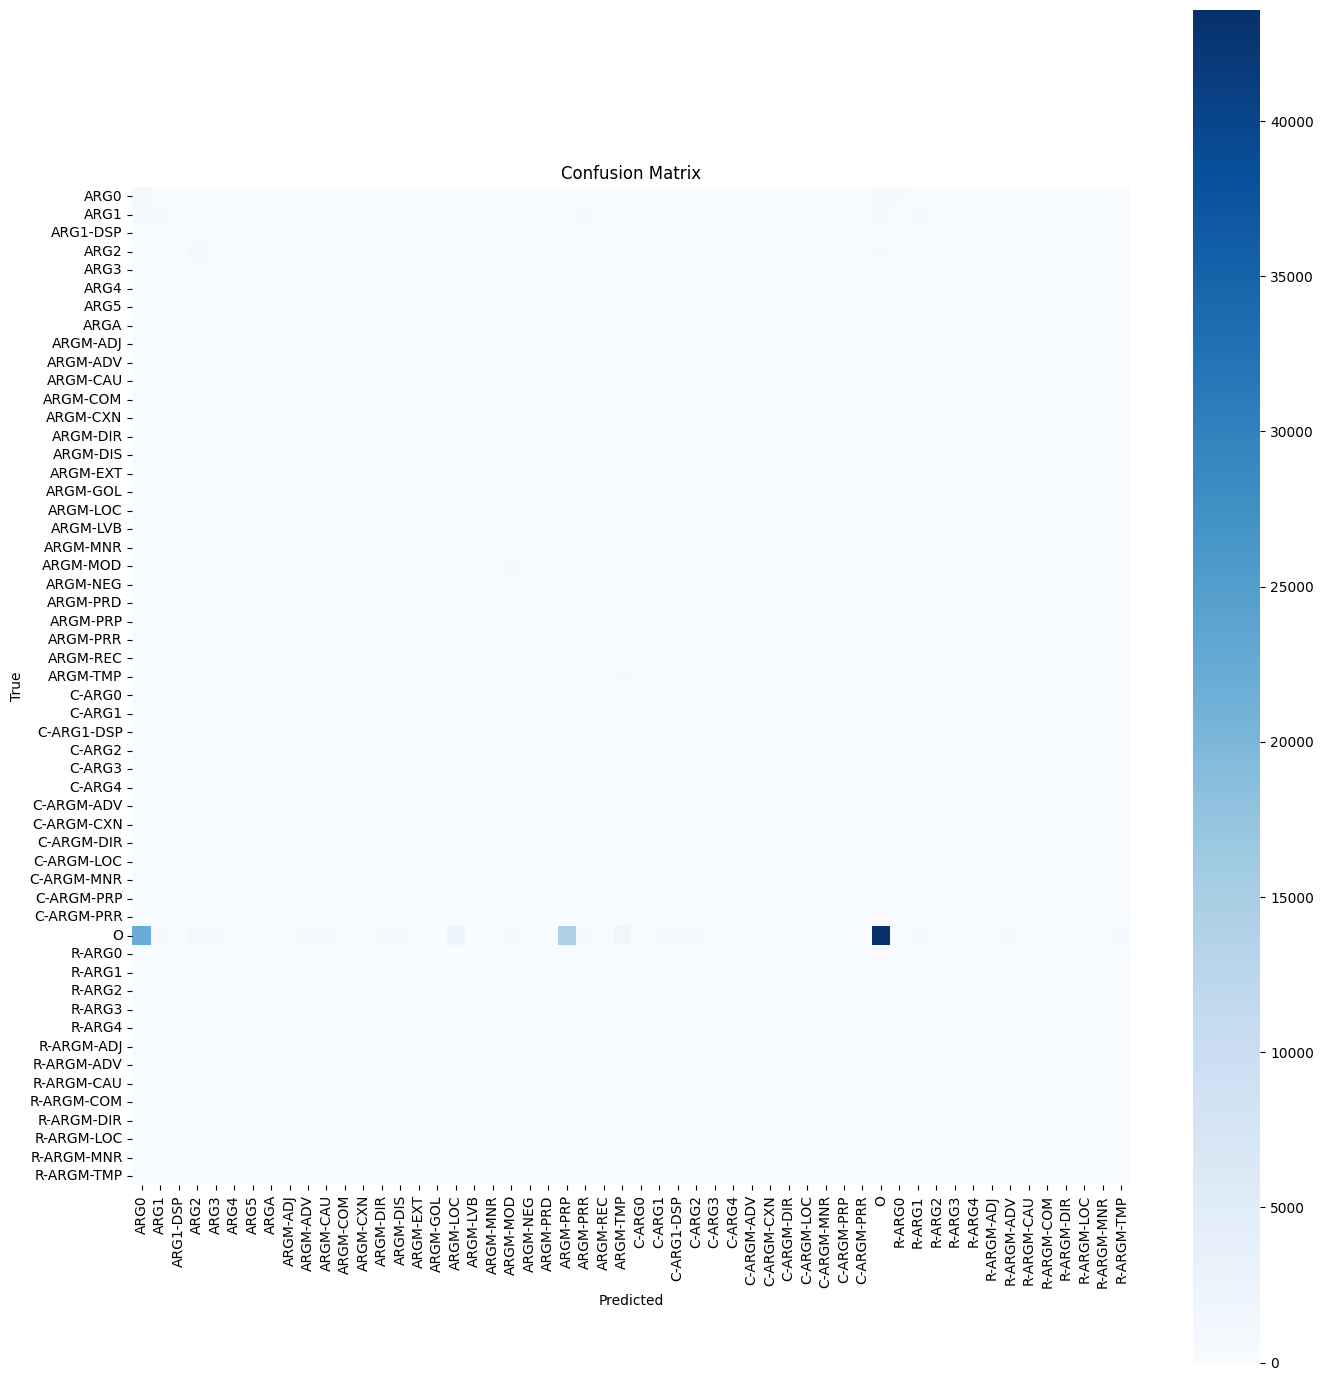

In [ ]:
plt.figure(figsize=(14, 14))
sns.heatmap(
    cm_df,              
    cmap="Blues",
    square=True,
    cbar=True
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()
plt.close()

### Confusion matrix without "0"

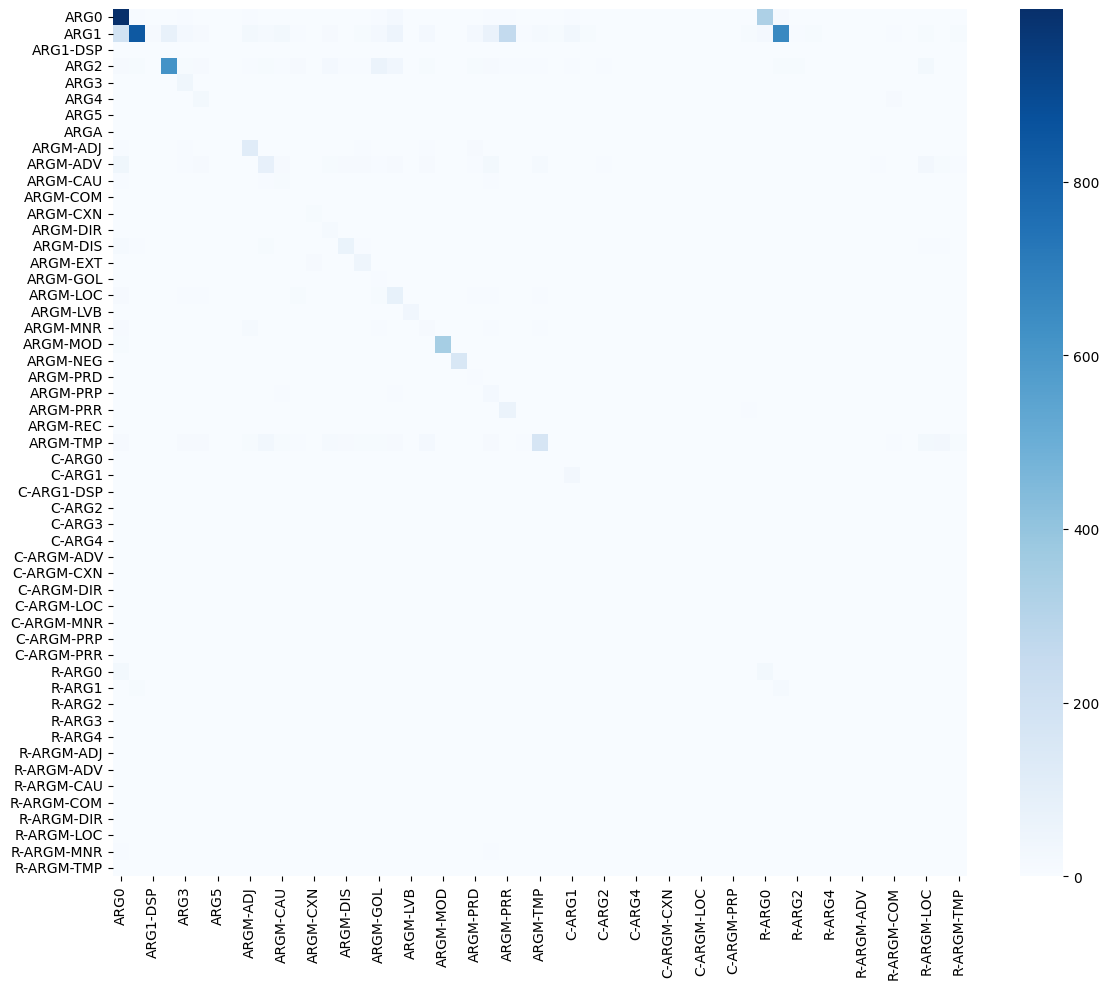

In [29]:
if "O" in cm_df.index:
    cm_df_no_o = cm_df.drop(index="O", columns="O")

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_df_no_o, cmap="Blues")
    plt.tight_layout()
    plt.show()
    plt.close()

**Discussion**

After 2000 iterations, the model did not reach the convergence state in training, which was specified if the loss is less than 1e-4. However, the model still observed some statistical impression such as the f1-score over ARG-0 was the highest figure among others, which implied the learning ability of the model over the class. Following, the argument (ARGM-NEG) representing the negation in the sentence had the f1-score as 0.647, which is slightly larger than that figure of outside argument (O). This achievement also highlights the fact that even the model still extract some meaningful features over minor classes.

Even though the class imbalance imposed a tough challenge for the LR model but it is observed an constrating behaviours when some actual outsides were classified as major classes, such as ARG0, ARG1, ARG2, or some minor ones, such as ARGM-PRR. This behaviour is still unexplainable, however one assumsed reason is that the characteristic of balancing classes of 'SAGA' optimization strategy in learning forced the model to exceedingly learn over minor. Probably, some modifications are needed to capture these particular behaviours accuractely. 

### Save test prediction 

In [ ]:
output_file = f"LRtest_predictions.tsv"

with open(output_file, "w", newline="", encoding="utf-8") as f:
  writer = csv.writer(f, delimiter="\t")

  writer.writerow(["token", "gold_label", "predicted_label"])

  for example in test["instances"]:
    tokens = example["tokens"]
    for token, p, l in zip(tokens, y_pred, y_test):
      #print(token, p, l)
      writer.writerow([token, l, p])

    writer.writerow([])

### Custom Sentence Testing

In [38]:
def predict_sentence(sentence, predicate_index, vec=vec, clf=clf):
    """
    Predict SRL labels for all tokens in a sentence given a predicate index.
    """
    tokens = sentence.split()
    if predicate_index < 0 or predicate_index >= len(tokens):
        raise ValueError("predicate_index out of range")

    doc = create_doc(tokens)

    X_dict = []
    for i in range(len(tokens)):
        feats = {
            "dep_path_predlemma": dependency_path_plus_pred_lemma(doc, i, predicate_index),
            "ner": feature_ner(doc, i),
            "dist_to_pred": feature_signed_distance(i, predicate_index, bucket=True),
        }
        # print(feats)
        X_dict.append(feats)

    X = vec.transform(X_dict)
    y_pred = clf.predict(X)
    print("Predicate:", predicate_index, tokens[predicate_index])
    for i, (t, lab) in enumerate(zip(tokens, y_pred)):
        mark = "<PRED>" if i == predicate_index else ""
        print(f"{i:2d}  {t:15}  {lab:10} {mark}")

In [36]:
sentence = "I go to  Viet Nam in this summer"
tokens = sentence.split()
pred_i = 1  # "go"

predict_sentence(tokens, pred_i)

Predicate: 1 go
 0  I                ARG0       
 1  go               O          <PRED>
 2  to               C-ARG4     
 3  Viet             ARG4       
 4  Nam              ARG4       
 5  in               C-ARG4     
 6  this             ARGM-TMP   
 7  summer           R-ARGM-COM 


In [37]:
sentence = "Bob gave Lili a book yesterday"
tokens = sentence.split()
pred_i = 1  # "gave"

predict_sentence(tokens, pred_i)

Predicate: 1 gave
 0  Bob              ARG0       
 1  gave             O          <PRED>
 2  Lili             ARG2       
 3  a                O          
 4  book             ARGM-PRR   
 5  yesterday        ARGM-TMP   


In [42]:
sentence = "it reported that the predrodollar increased 10% today "
pred_i = 1  # "reported"
predict_sentence(sentence, pred_i)

sentence = "it reported that the predrodollar increased 10% today "
pred_i = 5  # "increased"
predict_sentence(sentence, pred_i)

Predicate: 1 reported
 0  it               R-ARG0     
 1  reported         O          <PRED>
 2  that             O          
 3  the              O          
 4  predrodollar     O          
 5  increased        ARG1       
 6  10%              O          
 7  today            ARGM-TMP   
Predicate: 5 increased
 0  it               O          
 1  reported         O          
 2  that             O          
 3  the              O          
 4  predrodollar     O          
 5  increased        O          <PRED>
 6  10%              ARG1       
 7  today            ARGM-TMP   


In [45]:

sentence = "it reported that 500 people were killed in gaza "
pred_i = 5  # "were"
predict_sentence(sentence, pred_i)

sentence = "it reported that 500 people were killed in gaza "
pred_i = 6  # "killed"
predict_sentence(sentence, pred_i)

Predicate: 5 were
 0  it               O          
 1  reported         O          
 2  that             O          
 3  500              O          
 4  people           R-ARG1     
 5  were             O          <PRED>
 6  killed           ARG2       
 7  in               O          
 8  gaza             ARGM-LOC   
Predicate: 6 killed
 0  it               O          
 1  reported         O          
 2  that             O          
 3  500              O          
 4  people           R-ARG1     
 5  were             O          
 6  killed           O          <PRED>
 7  in               O          
 8  gaza             ARGM-LOC   


**Discussion**

In surface, the model performed quite well to some simple active and specially passive sentences if the given predicates are specicfied as the action (not auxilary verb). Other modifications such temporal (ARGM-TMP) or location (ARGM-LOC) or general (ARG4) modification arguments were observed in the predicted labels in a noticeable frequency. 

**Extract dependency file**

In [60]:
import json
import re

notebook_path = "main.ipynb"

with open(notebook_path) as f:
    nb = json.load(f)

imports = set()

for cell in nb["cells"]:
    if cell["cell_type"] == "code":
        source = "".join(cell["source"])
        matches = re.findall(r"^\s*(?:import|from)\s+([a-zA-Z0-9_]+)", source, re.MULTILINE)
        imports.update(matches)

imports = sorted(imports)

with open("requirements.txt", "w") as f:
    for pkg in imports:
        f.write(pkg + "\n")

requirements.txt created with detected imports:
['csv', 'datetime', 'joblib', 'matplotlib', 'pandas', 'seaborn', 'sklearn', 'spacy', 'token', 'typing']
